#**Startup Sales Trend Analysis Model**

This model takes your startup’s daily sales data, cleans it, and converts it into a clear, structured time series that shows how your sales change over time. Instead of guessing future performance, the model uses past trends, weekly patterns, and seasonal behavior to accurately predict future sales using the Prophet forecasting algorithm. It helps you understand whether sales are rising, falling, or staying stable—and how much you can expect to sell in the coming days or weeks.

By forecasting sales in advance, your startup can plan inventory, manage cash flow, schedule staff, prepare marketing campaigns, and make smarter business decisions. This model gives you a clear view of upcoming demand, reduces risks, and supports long-term growth through reliable, data-driven forecasting.

**Steps:**

**1. Import Data File**

Upload the sales CSV file so the model can access the raw sales information.

**2. Load the Dataset**

Read the uploaded file into a DataFrame to make the data ready for analysis.

**3. Dataset Overview**

Check column names, data types, and dataset shape to understand the structure of the sales data.

**4. Clean data**

Fix date formats, remove invalid rows, and create the sales column to ensure accurate forecasting.

**5. Group by Daily Sales**

Convert all transactions into daily total sales to build a proper time series for the model.

**6. Visualize Daily Sales**

Plot daily sales trends to observe patterns, spikes, and seasonality in sales behavior.

**7. Install Prophet Library**

Set up the Prophet forecasting tool required for trend analysis and predictions.

**8. Build Forecast Model**

Train the Prophet model on past daily sales to learn trends, weekly patterns, and seasonal effects.

**9. Forecast Future Sales**

Generate predictions for the upcoming days, including lower and upper expected sales ranges.

**10. Plot Sales Forecast**

Visualize historical sales along with the future forecast on a clear timeline chart.

**11. Split Data into Train and Test Sets**

Set aside the last 30 days as test data to check how well the model predicts real sales.

**12. Train Model**

Retrain Prophet using only training data to prepare for model evaluation.

**13. Train Prophet Model on Training Data**

Fit the Prophet model again on the training dataset for validation purposes.

**14. Predict Sales for Test Period**

Forecast the next 30 days and compare predictions with actual sales.

**15. Extract Actual and Predicted Values**

Collect real sales values (y_true) and predicted values (y_pred) for accuracy testing.

**16. Calculate Model Error Metrics**

Evaluate model performance using MAE and RMSE to measure how close predictions are to actual sales.

**17. Visualize Actual vs Predicted Sales**

Plot actual and predicted sales together to visually judge model accuracy.

**1. Import Data File**

In [1]:
from google.colab import files
uploaded = files.upload()


Saving retail_data.csv to retail_data.csv


This code opens a file upload box and lets you select your retail sales CSV file. Once uploaded, it stores the file so the notebook can load and use the dataset for the forecasting model.

**2. Load the Dataset**

In [2]:
import pandas as pd

DATA_PATH = list(uploaded.keys())[0]
df = pd.read_csv(DATA_PATH)
df.head()


,customer_id,age,gender,income_bracket,loyalty_program,membership_years,churned,marital_status,number_of_children,education_level,...,distance_to_store,holiday_season,season,weekend,customer_support_calls,email_subscriptions,app_usage,website_visits,social_media_engagement,days_since_last_purchase
0,1,56,Other,High,No,0,No,Divorced,3,Bachelor's,...,33.21,No,Spring,Yes,5,No,High,30,High,40
1,2,69,Female,Medium,No,2,No,Married,2,PhD,...,62.56,No,Summer,Yes,6,No,High,40,Medium,338
2,3,46,Female,Low,No,5,No,Married,3,Bachelor's,...,83.04,Yes,Winter,Yes,2,Yes,Low,89,Medium,61
3,4,32,Female,Low,No,0,No,Divorced,2,Master's,...,50.43,Yes,Winter,No,12,No,Low,12,Low,42
4,5,60,Female,Low,Yes,7,Yes,Divorced,2,Bachelor's,...,36.55,Yes,Summer,Yes,3,No,Medium,31,Low,242


This code reads the uploaded CSV file into a pandas DataFrame so the model can start working with the sales data.

**3. Dataset Overview**

In [3]:
df.info()
df.head()
df.columns
df.shape


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 78 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   customer_id                1000000 non-null  int64  
 1   age                        1000000 non-null  int64  
 2   gender                     1000000 non-null  object 
 3   income_bracket             1000000 non-null  object 
 4   loyalty_program            1000000 non-null  object 
 5   membership_years           1000000 non-null  int64  
 6   churned                    1000000 non-null  object 
 7   marital_status             1000000 non-null  object 
 8   number_of_children         1000000 non-null  int64  
 9   education_level            1000000 non-null  object 
 10  occupation                 1000000 non-null  object 
 11  transaction_id             1000000 non-null  int64  
 12  transaction_date           1000000 non-null  object 
 13  product_id   

(1000000, 78)

This code shows the dataset’s structure, first few rows, column names, and overall size. It helps you understand what data you have before cleaning or analysis.

**4. Clean data**

In [4]:
df.rename(columns={'transaction_date': 'date'}, inplace=True)


This code renames the transaction_date column to date to keep the dataset clean and consistent.

In [5]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.dropna(subset=['date'])
df.head()


,customer_id,age,gender,income_bracket,loyalty_program,membership_years,churned,marital_status,number_of_children,education_level,...,distance_to_store,holiday_season,season,weekend,customer_support_calls,email_subscriptions,app_usage,website_visits,social_media_engagement,days_since_last_purchase
0,1,56,Other,High,No,0,No,Divorced,3,Bachelor's,...,33.21,No,Spring,Yes,5,No,High,30,High,40
1,2,69,Female,Medium,No,2,No,Married,2,PhD,...,62.56,No,Summer,Yes,6,No,High,40,Medium,338
4,5,60,Female,Low,Yes,7,Yes,Divorced,2,Bachelor's,...,36.55,Yes,Summer,Yes,3,No,Medium,31,Low,242
5,6,25,Other,Medium,Yes,4,Yes,Divorced,0,Bachelor's,...,66.71,Yes,Summer,No,4,Yes,Medium,80,High,147
9,10,75,Male,Medium,No,3,No,Married,2,High School,...,59.66,Yes,Spring,Yes,0,No,Medium,57,High,309


This code converts the date column into a proper datetime format and removes any rows with invalid dates to ensure the time series is accurate.

In [6]:
if 'quantity' in df.columns and 'price' in df.columns:
    df['sales'] = df['quantity'] * df['price']


This code calculates the total sales amount by multiplying quantity and price for each transaction.

In [7]:
# If your date column is named transaction_date
df.rename(columns={'transaction_date': 'date'}, inplace=True)

df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.dropna(subset=['date'])

# If total_sales column exists, use it
if 'total_sales' in df.columns:
    df['sales'] = df['total_sales']
else:
    df['sales'] = df['quantity'] * df['unit_price']

# GROUP BY DAILY SALES
daily = df.groupby(df['date'].dt.date)['sales'].sum().reset_index()
daily.columns = ['ds', 'y']
daily['ds'] = pd.to_datetime(daily['ds'])

daily.head()


,ds,y
0,2020-01-01,7003561.78
1,2020-01-02,6879727.50
2,2020-01-03,6601543.08
3,2020-01-04,6810607.48
4,2020-01-05,6679939.95


This code cleans the date column, creates a proper sales column, and then groups all transactions by date to calculate total daily sales. The result is converted into the format required by Prophet (ds for date and y for sales), preparing the data for forecasting.

**5. Visualize Daily Sales**

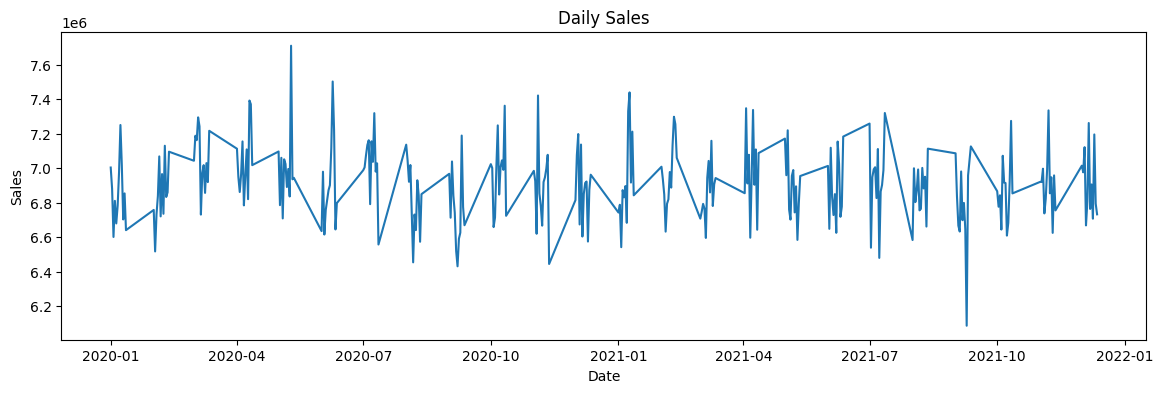

In [8]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14,4))
plt.plot(daily['ds'], daily['y'])
plt.title("Daily Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()


This code creates a line chart showing how sales change from day to day. By plotting daily sales, you can easily spot important patterns such as increasing or decreasing trends, sudden spikes, slow periods, weekly patterns, and seasonal behavior. This visual understanding is important before training a forecasting model because it shows how stable or variable your sales data is over time.

**6. Install Prophet Library**

In [9]:
!pip install prophet


This command installs the Prophet forecasting library, which is used to build the sales prediction model. Prophet helps analyze trends, seasonality, and future sales patterns.

**7. Build Forecast Model**

In [10]:
from prophet import Prophet

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

model.fit(daily)


This code creates a Prophet model with yearly and weekly seasonality enabled, then fits it to the daily sales data. By training on past sales patterns, the model learns trends and seasonal behavior so it can accurately forecast future sales.

**8. Forecast Future Sales**

In [11]:
future = model.make_future_dataframe(periods=90)
forecast = model.predict(future)

forecast[['ds','yhat','yhat_lower','yhat_upper']].tail()


,ds,yhat,yhat_lower,yhat_upper
373,2022-03-08,6.937837e+06,6.671883e+06,7.183161e+06
374,2022-03-09,6.948658e+06,6.686451e+06,7.188438e+06
375,2022-03-10,6.886849e+06,6.635921e+06,7.141922e+06
376,2022-03-11,6.860714e+06,6.612737e+06,7.131452e+06
377,2022-03-12,6.894471e+06,6.650830e+06,7.166866e+06


This code creates a future timeline of 90 days and asks the trained Prophet model to predict sales for each upcoming date. The forecast includes the main prediction (yhat) as well as yhat_lower and yhat_upper, which show the possible minimum and maximum sales. This helps understand both expected sales and the uncertainty range.

**Save Forecast**

In [12]:
forecast[['ds','yhat','yhat_lower','yhat_upper']].to_csv("sales_forecast_output.csv", index=False)


This code exports the forecasted sales (with dates and confidence ranges) to a CSV file so you can download and use the results for reports or analysis.

**9. Plot Sales Forecast**

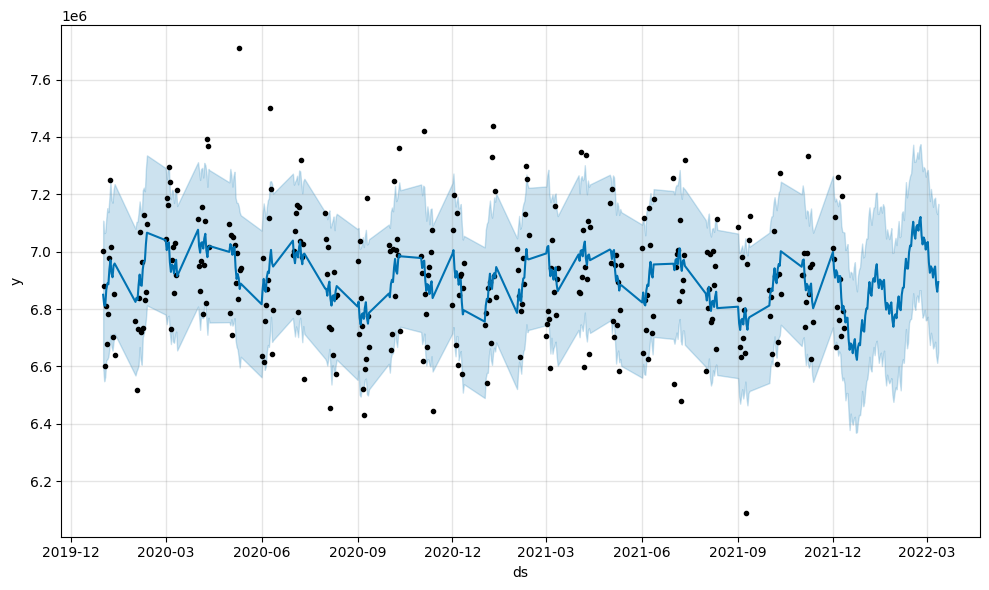

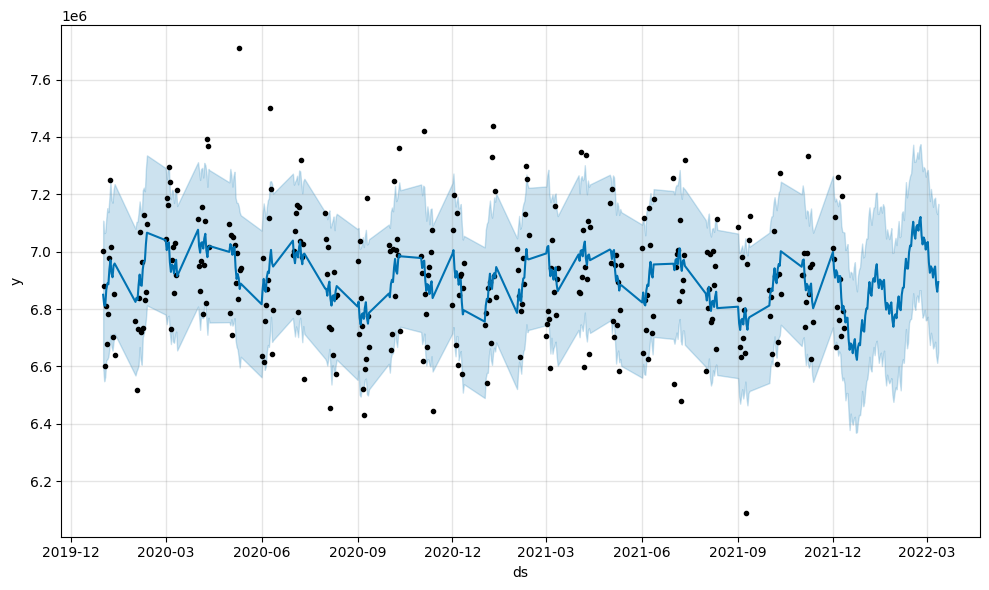

In [14]:
model.plot(forecast)


This code creates the main Prophet forecast plot, showing historical sales along with predicted future sales and their uncertainty bands.

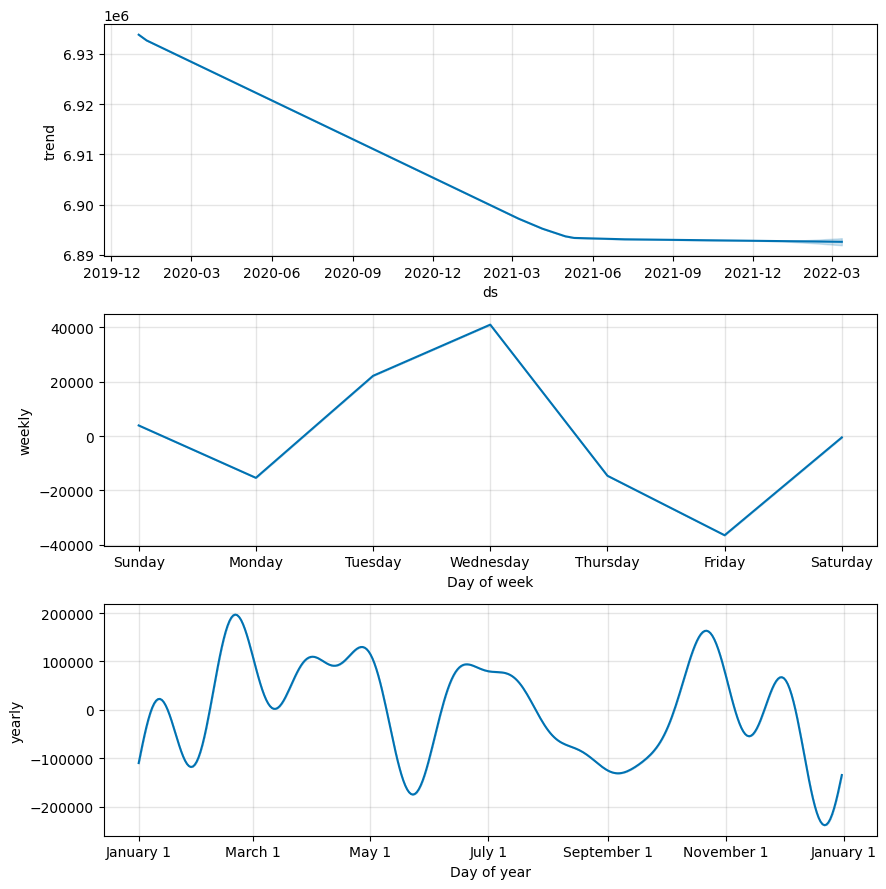

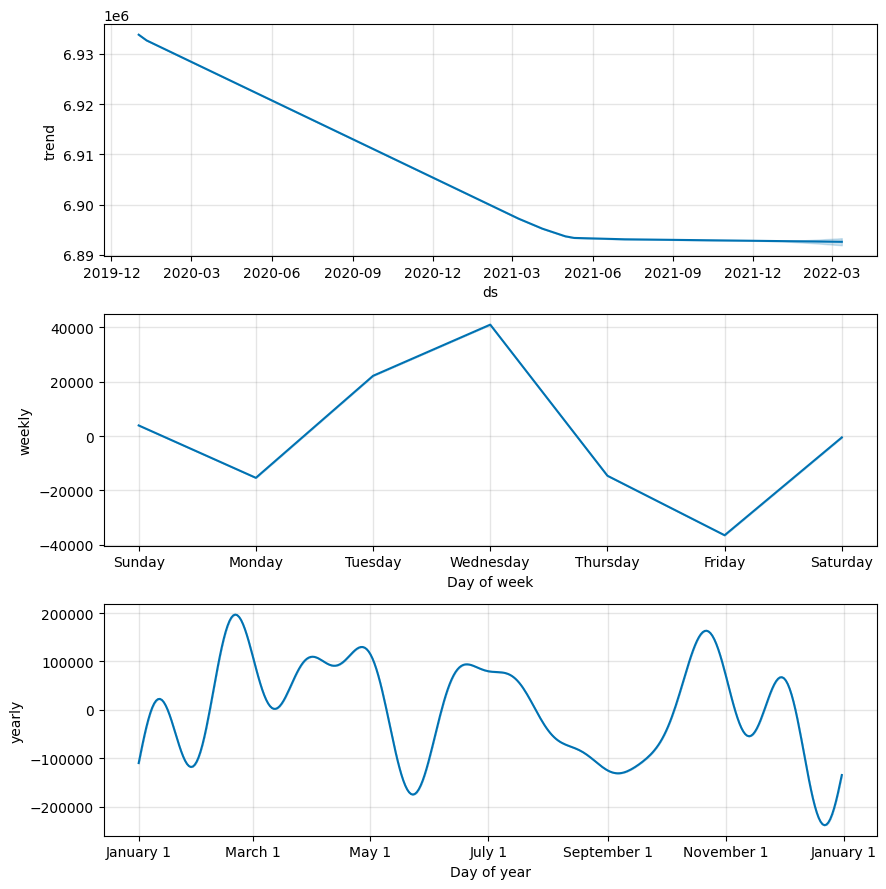

In [15]:
model.plot_components(forecast)


This code displays Prophet’s component plots, which break the forecast into trend, weekly patterns, and seasonal effects. It helps you understand what drives the predicted sales.

**Train & Test Model**

**10. Split Data into Train and Test Sets**

In [16]:
train = daily[:-30]     # all data except last 30 days
test = daily[-30:]      # last 30 days (actual real sales)


This code separates the daily sales data into two parts:

Train: all days except the last 30 (used to train the model)

Test: the last 30 days (used to check how well the model predicts real sales)

This helps evaluate the forecasting model’s accuracy.

**11. Train Prophet Model on Training Data**

In [17]:
from prophet import Prophet

m_test = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

m_test.fit(train)


This code creates a new Prophet model with yearly and weekly seasonality enabled and trains it using only the training dataset. This allows the model to learn past sales patterns before making predictions on the test data.

**12. Predict Sales for Test Period**

In [18]:
future_test = m_test.make_future_dataframe(periods=30)
pred = m_test.predict(future_test)


This code creates the next 30 days of future dates and uses the trained model to predict sales for those days. These predictions will later be compared with the actual sales in the test set.

**13. Extract Actual and Predicted Values**

In [19]:
y_pred = pred['yhat'][-30:].values     # predicted values
y_true = test['y'].values              # actual values


This code takes the last 30 predicted sales values from the model and stores them as y_pred, and takes the actual last 30 days of sales from the test data as y_true. These two arrays will be compared to measure forecasting accuracy.

**14. Calculate Model Error Metrics**

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print("Model Testing Results:")
print("MAE:", mae)
print("RMSE:", rmse)


Model Testing Results:
MAE: 190191.74716458123
RMSE: 222905.88422951882


This code compares the actual sales (y_true) with the predicted sales (y_pred) and calculates two accuracy metrics:

MAE (Mean Absolute Error): the average difference between actual and predicted sales

RMSE (Root Mean Squared Error): how large the prediction errors are overall

These values show how well the forecasting model performed.

**15. Visualize Actual vs Predicted Sales**

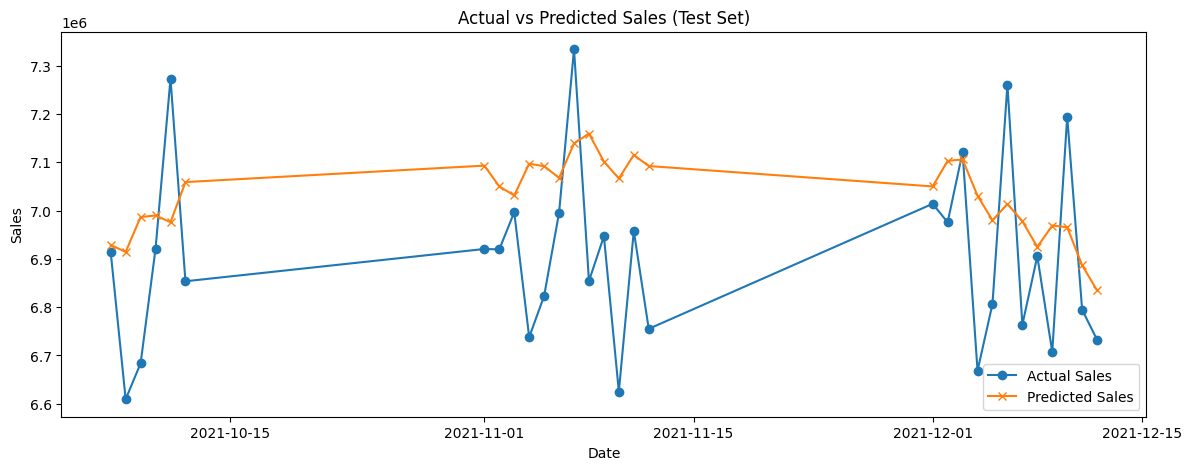

In [21]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14,5))

plt.plot(test['ds'], y_true, label='Actual Sales', marker='o')
plt.plot(test['ds'], y_pred, label='Predicted Sales', marker='x')

plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Actual vs Predicted Sales (Test Set)")
plt.legend()
plt.show()


This code plots the actual sales and the model’s predicted sales for the test period (last 30 days). By showing both lines together, it helps you visually compare how close the predictions are to real sales and understand the model’s performance.

**16. Download Forecast Output File**

In [22]:
from google.colab import files
files.download("sales_forecast_output.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

This code downloads the CSV file containing the forecasted sales results so you can save it to your computer for reporting or further analysis.